In [1]:
import os
import certifi  
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults # internet search tool

from langchain import hub
from langsmith import Client

import requests

In [2]:
from langchain.agents import create_react_agent, AgentExecutor # reasoning and action agent

In [3]:
os.environ["SSL_CERT_FILE"] = certifi.where()  # Set the SSL certificate file path
load_dotenv()  # Load environment variables from .env file

# Initialize the TavilySearchResults tool
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
WEATHERSTACK_API_KEY = os.getenv("WEATHERSTACK_API_KEY")

In [4]:
# Initialize the TavilySearchResults tool with the API key and maximum results

search_tool = TavilySearchResults(
    tavily_api_key=TAVILY_API_KEY,
    max_results=3)

In [5]:
# Custom tool to fetch weather data using the Weatherstack API
@tool
def get_weather_data(city: str) -> str:
    """
    Fetch current weather information for a city.
    """

    url = (
        f"http://api.weatherstack.com/current?"
        f"access_key={WEATHERSTACK_API_KEY}&query={city}"
    )

    response = requests.get(url)

    data = response.json()

    if "current" not in data:
        return f"Could not fetch weather data for {city}"

    return (
        f"City: {city}\n"
        f"Temperature: {data['current']['temperature']}°C\n"
        f"Weather: {data['current']['weather_descriptions'][0]}\n"
        f"Humidity: {data['current']['humidity']}%"
    )

In [6]:
result = search_tool.invoke("What is the latest news about AI?")

In [7]:
result

[{'url': 'https://www.artificialintelligence-news.com',
  'content': "Cybersecurity AI\n\nAugust 18, 2026\n\n### Okta targets AI agent token costs with MCP scoping\n\nData Engineering & MLOps\n\nAugust 13, 2026\n\n### Red Hat, NVIDIA, IBM back project turning AI policy into code\n\nGovernance, Regulation & Policy\n\nAugust 4, 2026\n\n#### Industries\n\n### HoneyBook bets on agentic AI to streamline small business operations with its new Claude connector\n\nWorld of Work\n\nAugust 6, 2026\n\n### Zuckerberg details Meta’s personal AI superintelligence strategy\n\nAI and Us\n\nJuly 30, 2026\n\n### Google’s Gemini 3.6 Flash targets enterprise agent token costs\n\nAI in Action\n\nJuly 21, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026 [...] AI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\

In [8]:
# Initialize the ChatOpenAI model with the API key and temperature

llm = ChatOpenAI(
    openai_api_key = OPENAI_API_KEY,
    temperature = 0,
    model_name = "gpt-3.5-turbo",
    )


In [9]:
response = llm.invoke("What is the Year it is ?")

In [10]:
response

# the reason it is giving the year 2023 because the model's knowledge cutoff is in 2023, and it does not have access to real-time information.

AIMessage(content='I am an AI assistant and I do not have the ability to know the current year. Please check your device or search online for the current year.', response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 14, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-8639bbdf-f190-4743-8ca1-6dd021315e8e-0')

In [11]:
# initialize the Prompt

from langsmith import Client

client = Client()
prompt = client.pull_prompt("hwchase17/react")

In [12]:
# initialize the tools list with the search tool
tools = [search_tool, get_weather_data]

In [13]:
# Create the agent using the ReAct framework with the LLM, tools, and prompt

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt
    )

In [14]:
# create agent executor to run the agent with verbose output.

agent_executor = AgentExecutor(
    agent=agent, 
    tools=tools, 
    verbose=True
    )

In [15]:
# Run the agent executor with a query to find the latest news about AI and summarize it.

response = agent_executor.invoke({
    "input": (
        "What is Temperature in London ?"
        )
})



> Entering new AgentExecutor chain...
I should use the get_weather_data tool to find the current temperature in London.
Action: get_weather_data
Action Input: "London"City: London
Temperature: 18°C
Weather: Light rain shower
Humidity: 86%I have the current temperature in London.
Final Answer: The temperature in London is 18°C.

> Finished chain.


In [16]:
print(response["output"])

The temperature in London is 18°C.


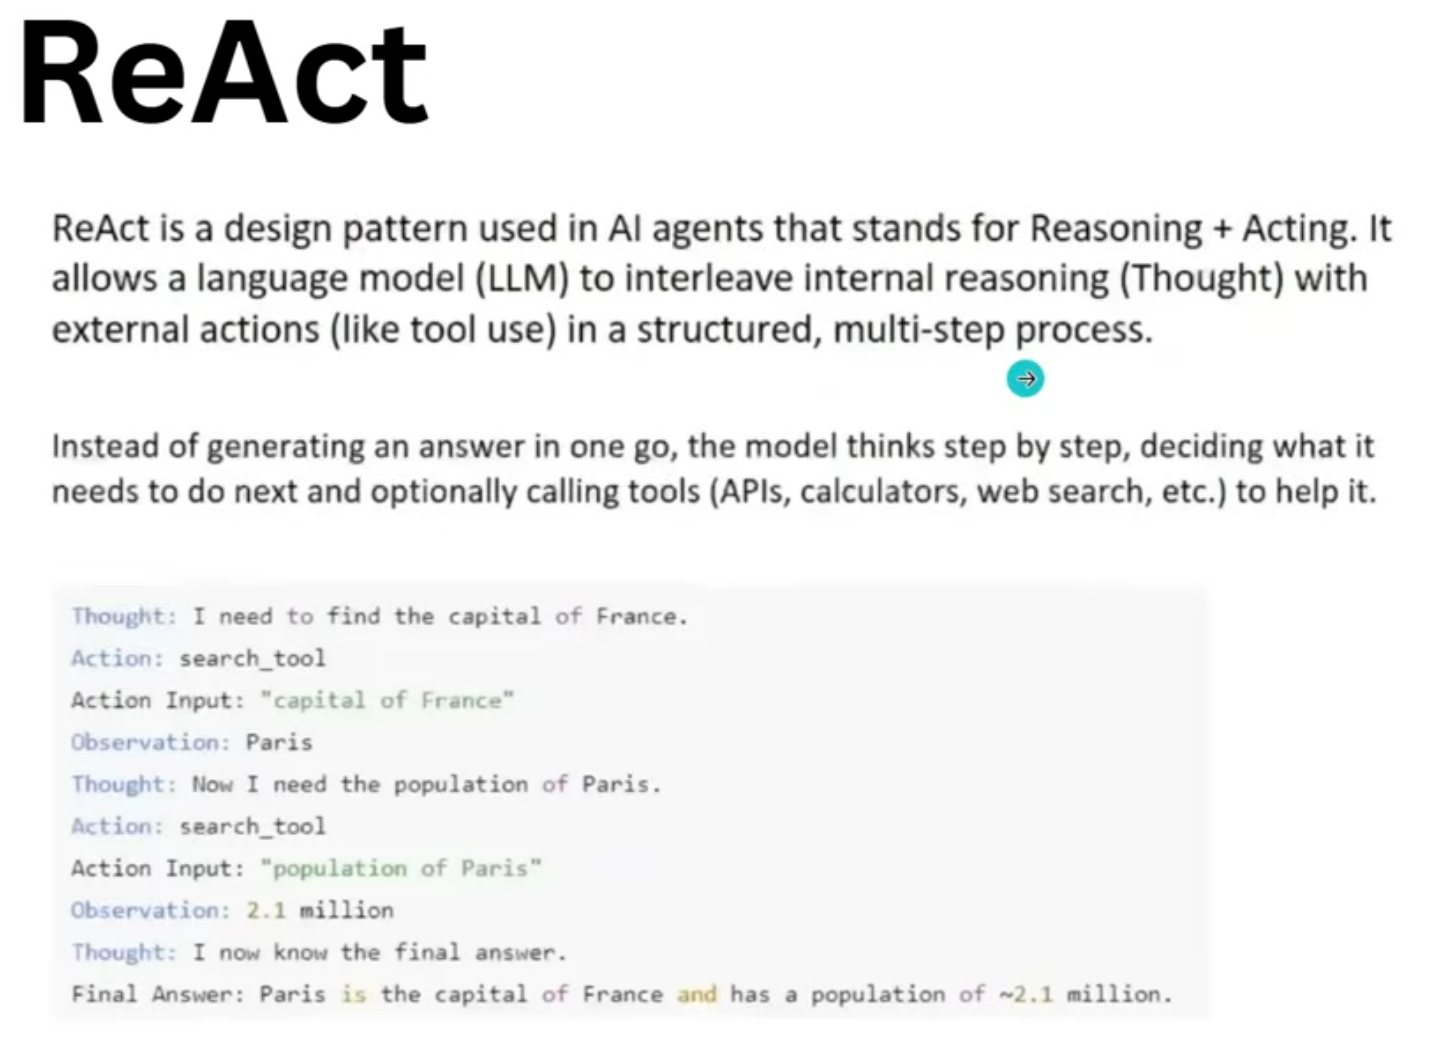  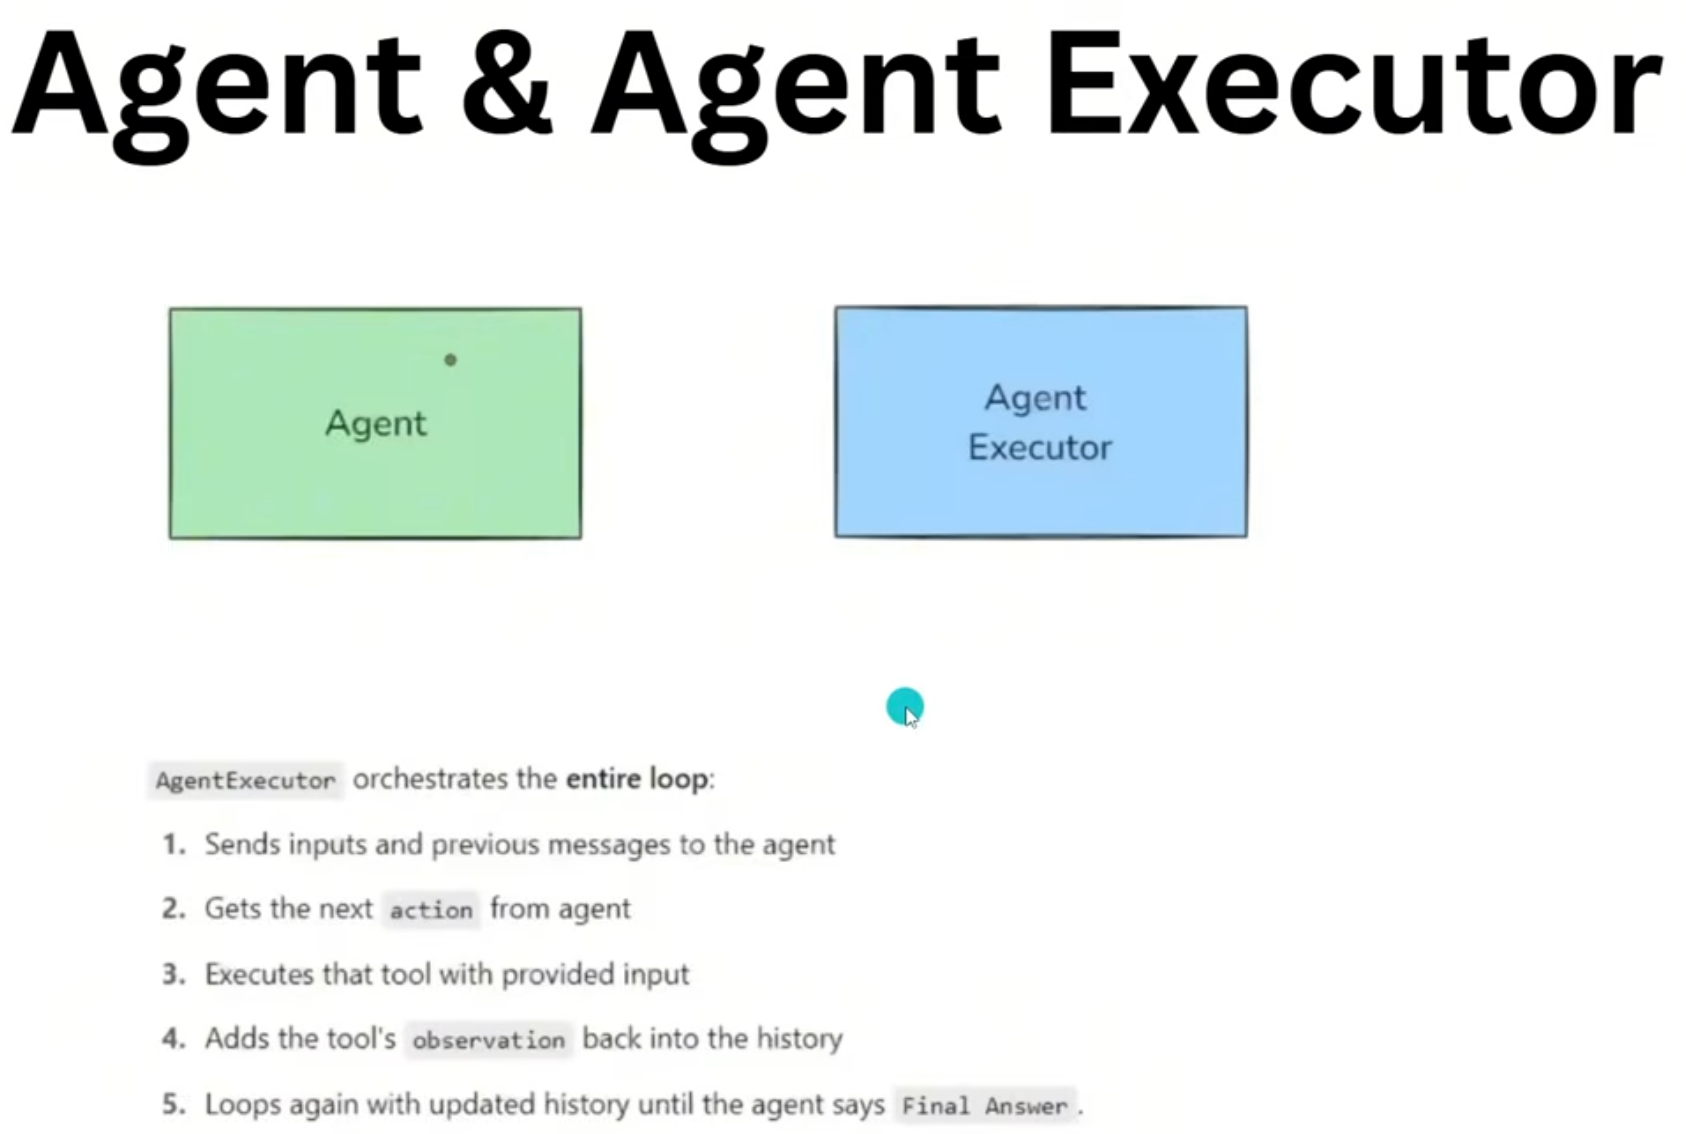